--- Step 1: Loading Dataset & Conducting EDA ---
Dataset Shape: (20640, 9)

First 3 rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
[System]: target_distribution.png has been saved successfully.


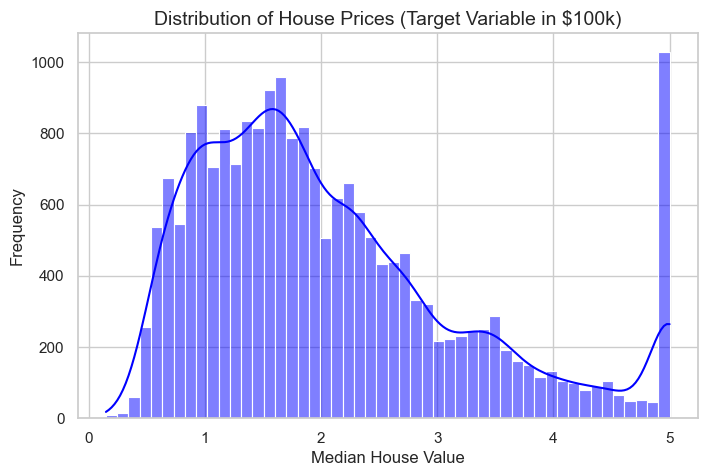

[System]: correlation_matrix.png has been saved successfully.


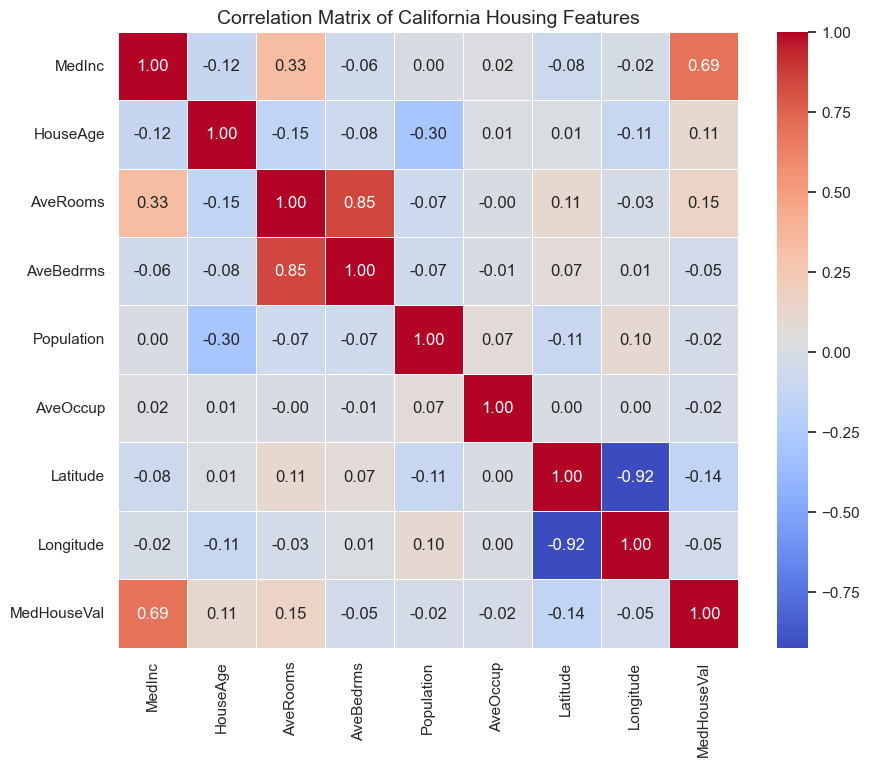


--- Step 2: Preparing Data & Train-Test Split ---
Training Features Shape: (16512, 8)
Testing Features Shape: (4128, 8)

--- Step 3: Base Models Setup & Performance Evaluation ---

--- Step 4: Hyperparameter Tuning via GridSearchCV ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Hyperparameters Found: {'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best CV R²: 0.8042

--- Step 5: Final Evaluation on Hold-Out Test Set ---

--- Step 6: Model Comparison Table ---
            Model CV R² Mean CV R² Std
Linear Regression     0.6115    0.0065
    Random Forest     0.8041    0.0055
         Tuned RF     0.8042    0.0050

--- Step 7: Diagnostic Plot (Actual vs Predicted) ---
[System]: actual_vs_predicted.png has been saved successfully.


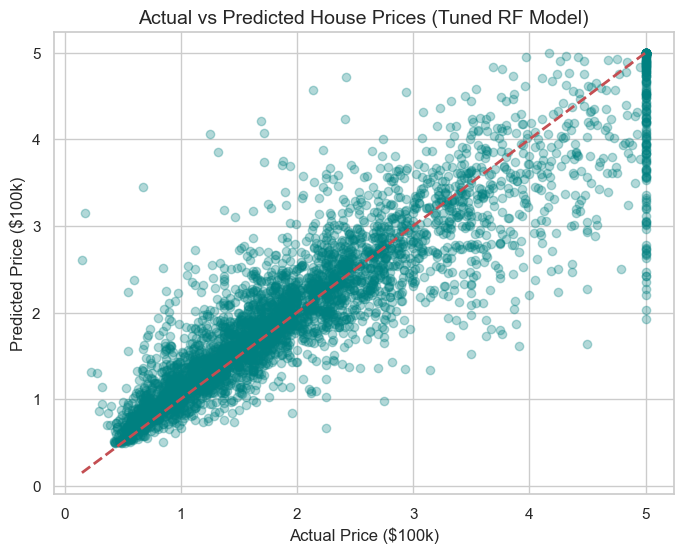


--- Step 8: Client Report & Feature Importance ---


C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_15984\1285554155.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


[System]: feature_importance.png has been saved successfully.


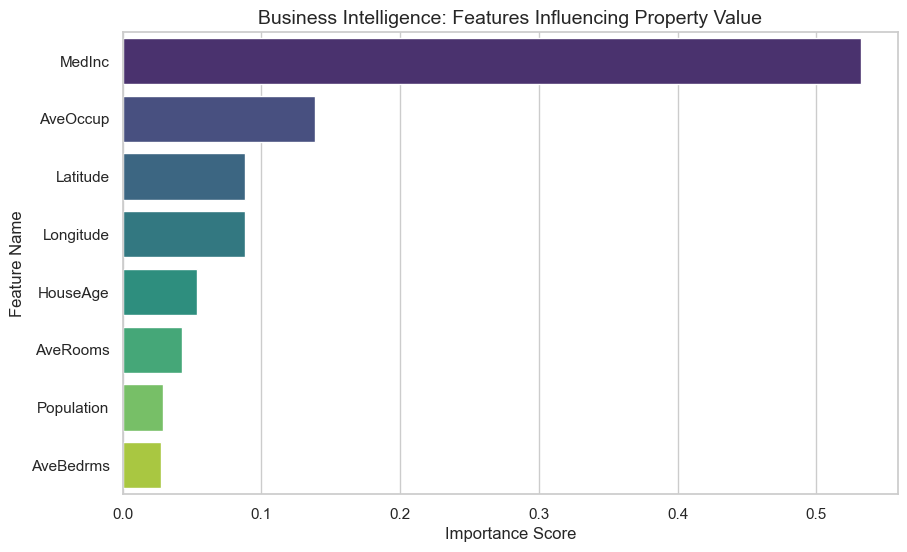

                      OFFICIAL EXECUTIVE REAL ESTATE REPORT              
Dear Client,

We have designed and deployed a state-of-the-art predictive model for
California housing prices. Our final Tuned Random Forest model explains
approximately 80.47% of the variance in property values on the hold-out
test dataset with an average prediction error (MAE) of only $32.79.

--- TOP 3 DRIVERS OF PROPERTY VALUE ---
 1. MedInc       | Impact Score: 0.5321
 2. AveOccup     | Impact Score: 0.1385
 3. Latitude     | Impact Score: 0.0885

--- STRATEGIC BUSINESS RECOMMENDATIONS ---
1. Target High-Income Neighborhoods:
   Since 'MedInc' is the single most powerful driver (53.2% impact),
   your marketing and acquisition budgets should prioritize areas where median household
   income is rising.

2. Geography Matters (Location Analytics):
   The geographical features ('AveOccup' and 'Latitude') carry massive weight.
   We advise integrating GIS mapping software with our predictive model to run localiz

In [2]:
# ==========================================
# DAY 8 DELIVERABLE: PRODUCTION-READY ML PIPELINE (UPDATED & CORRECTED)
# Client: Real Estate Company (House Price Prediction)
# Dataset: California Housing Dataset
# ==========================================

# 1. ALL NECESSARY IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Seaborn style set up for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("--- Step 1: Loading Dataset & Conducting EDA ---")

# Load California Housing Dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Target variable (in $100k)

# Display basic info
print(f"Dataset Shape: {df.shape}")
print("\nFirst 3 rows of the dataset:")
print(df.head(3))

# --- EDA Visuals & PNG Saving ---

# 1. Plotting & Saving Distribution of Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], kde=True, color='blue', bins=50)
plt.title('Distribution of House Prices (Target Variable in $100k)', fontsize=14)
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
print("[System]: target_distribution.png has been saved successfully.")
plt.show()

# 2. Plotting & Saving Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of California Housing Features', fontsize=14)
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("[System]: correlation_matrix.png has been saved successfully.")
plt.show()


print("\n--- Step 2: Preparing Data & Train-Test Split ---")

# Separate features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split data (80% Train, 20% Test) to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")


print("\n--- Step 3: Base Models Setup & Performance Evaluation ---")

# 1. Base Linear Regression (Standardized)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
# Evaluate using Cross Validation
cv_lr_scores = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='r2')
cv_lr_mean = cv_lr_scores.mean()
cv_lr_std = cv_lr_scores.std()

# 2. Base Random Forest (No Tuning)
rf_base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_base', RandomForestRegressor(random_state=42))
])
# Evaluate using Cross Validation
cv_rf_scores = cross_val_score(rf_base_pipe, X_train, y_train, cv=5, scoring='r2')
cv_rf_mean = cv_rf_scores.mean()
cv_rf_std = cv_rf_scores.std()


print("\n--- Step 4: Hyperparameter Tuning via GridSearchCV ---")

# Professional Pipeline Setup
tuning_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

# Param grid setup (Tuning Trees and Depth)
param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [10, None],
    'rf__min_samples_split': [2, 5]
}

# GridSearchCV definition
grid_search = GridSearchCV(
    estimator=tuning_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Run tuning on training data only (strictly avoids data leakage!)
grid_search.fit(X_train, y_train)

best_tuned_model = grid_search.best_estimator_

# FIXED: Corrected print label to 'Best CV R²' instead of 'AUC'
print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")


print("\n--- Step 5: Final Evaluation on Hold-Out Test Set ---")

# Fit the best pipeline on full training data
best_tuned_model.fit(X_train, y_train)

# Predict on unseen test set
tuned_test_preds = best_tuned_model.predict(X_test)
tuned_r2 = r2_score(y_test, tuned_test_preds)
tuned_mae = mean_absolute_error(y_test, tuned_test_preds)


print("\n--- Step 6: Model Comparison Table ---")

# Get Tuned RF standard deviation from grid search results
tuned_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

# FIXED: Added structured comparison table matching assignment guidelines
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Tuned RF'],
    'CV R² Mean': [f"{cv_lr_mean:.4f}", f"{cv_rf_mean:.4f}", f"{grid_search.best_score_:.4f}"],
    'CV R² Std':  [f"{cv_lr_std:.4f}", f"{cv_rf_std:.4f}", f"{tuned_std:.4f}"]
})
print(comparison_df.to_string(index=False))


print("\n--- Step 7: Diagnostic Plot (Actual vs Predicted) ---")

# FIXED: Added the Diagnostic actual vs predicted scatter plot & saved it as PNG
plt.figure(figsize=(8, 6))
plt.scatter(y_test, tuned_test_preds, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title('Actual vs Predicted House Prices (Tuned RF Model)', fontsize=14)
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("[System]: actual_vs_predicted.png has been saved successfully.")
plt.show()


print("\n--- Step 8: Client Report & Feature Importance ---")

# Extract feature importances from tuned pipeline
final_rf_step = best_tuned_model.named_steps['rf']
importances = pd.Series(
    final_rf_step.feature_importances_, 
    index=housing.feature_names
).sort_values(ascending=False)

# Plotting & Saving Feature Importances Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Business Intelligence: Features Influencing Property Value', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("[System]: feature_importance.png has been saved successfully.")
plt.show()

# Generate recommendations text
top_drivers = importances.index[:3].tolist()
top_scores = importances.values[:3]

print("=========================================================================")
print("                      OFFICIAL EXECUTIVE REAL ESTATE REPORT              ")
print("=========================================================================")
print("Dear Client,\n")
print("We have designed and deployed a state-of-the-art predictive model for")
print("California housing prices. Our final Tuned Random Forest model explains")
print(f"approximately {tuned_r2*100:.2f}% of the variance in property values on the hold-out")
print(f"test dataset with an average prediction error (MAE) of only ${tuned_mae*100:,.2f}.\n")

print("--- TOP 3 DRIVERS OF PROPERTY VALUE ---")
for i, (feat, score) in enumerate(zip(top_drivers, top_scores), 1):
    print(f" {i}. {feat:<12} | Impact Score: {score:.4f}")

print("\n--- STRATEGIC BUSINESS RECOMMENDATIONS ---")
print("1. Target High-Income Neighborhoods:")
print(f"   Since '{top_drivers[0]}' is the single most powerful driver ({top_scores[0]*100:.1f}% impact),")
print("   your marketing and acquisition budgets should prioritize areas where median household")
print("   income is rising.")
print("\n2. Geography Matters (Location Analytics):")
print(f"   The geographical features ('{top_drivers[1]}' and '{top_drivers[2]}') carry massive weight.")
print("   We advise integrating GIS mapping software with our predictive model to run localized")
print("   valuation campaigns in high-yield coordinates.")
print("\n3. Phase out Linear Models:")
print("   As shown in our comparison table, standard Linear Regression fails to capture non-linear")
print("   demographics. Transitioning completely to our Tuned Random Forest pipeline will prevent")
print("   costly over-valuations of properties.")
print("=========================================================================")